# Cleaning

In [1]:
# Import, clean

import pandas as pd

games = pd.read_csv("data/games.csv")
matches = pd.read_csv("data/matches.csv")
tournaments = pd.read_csv("data/tour_meta.csv")

# Clean
# drop missing dates (games)
games['date'] = pd.to_datetime(games.date.str.split('(').str[0].str.strip())
games = games[pd.notna(games['date'])]
# sort by date
games.sort_values('date', inplace=True)

# clean dates (matches)
matches['date'] = pd.to_datetime(matches.date)
matches = matches[pd.notna(matches['date'])]
# sort by date
matches.sort_values('date', inplace=True)
# drop nan scores
matches = matches[pd.notna(matches['team1_score']) & pd.notna(matches['team2_score'])]

In [41]:
# Tournament attributes

import re
import pandas as pd

def map_tournament_attributes(matches: pd.DataFrame) -> pd.DataFrame:

    def get_region(name: str) -> str:
        if name.startswith("LEC"):
            return "LEC"
        if name.startswith(("LCK", "LCK Cup")):
            return "LCK"
        if name.startswith(("LPL", "LPL ")):
            return "LPL"
        if name.startswith(("LCS", "LTA", "LCP")):
            return "LCS"
        if name.startswith(("MSI", "Mid-Season Invitational")):
            return "INTL"
        if "World" in name or "Esports World Cup" in name:
            return "INTL"
        return "OTHER"

    def get_season(name: str) -> int | None:
        m = re.search(r"(20\d{2})", name)  # pl 2023/2024/2025
        return int(m.group(1)) if m else None

    def get_split(name: str) -> str:
        # Normalize split: Spring/Winter → Split1, Summer/Split2 → Split2, MSI/Worlds/EWC → International
        lowered = name.lower()
        if any(x in lowered for x in ["msi", "world", "esports world cup"]):
            return "International"
        if any(x in lowered for x in ["winter", "spring", "split 1"]):
            return "Split1"
        if any(x in lowered for x in ["summer", "split 2"]):
            return "Split2"
        return "Other"

    def get_stage(name: str) -> str:
        lowered = name.lower()
        if "groups" in lowered:
            return "Groups"
        if "playoffs" in lowered:
            return "Playoffs"
        if "regional finals" in lowered:
            return "Regional Finals"
        if "championship" in lowered:
            return "Championship"
        if "play-in" in lowered or "qualifying" in lowered:
            return "Qualifier"
        if "main event" in lowered:
            return "Main Event"
        # alap esetben Season
        if any(x in lowered for x in ["season", "split", "rounds"]):
            return "Season"
        return "Unknown"

    def is_international(name: str) -> int:
        lowered = name.lower()
        return 1 if any(x in lowered for x in ["msi", "world", "esports world cup"]) else 0

    def is_regional_final(name: str) -> int:
        return 1 if "regional finals" in name.lower() else 0

    matches["region"] = matches["tournament_name"].apply(get_region)
    matches["season"] = matches["tournament_name"].apply(get_season)
    matches["split"] = matches["tournament_name"].apply(get_split)
    matches["stage"] = matches["tournament_name"].apply(get_stage)
    matches["is_international"] = matches["tournament_name"].apply(is_international)
    matches["is_regional_final"] = matches["tournament_name"].apply(is_regional_final)

    return matches


tournaments = map_tournament_attributes(tournaments)
display(tournaments.sample(5))
print(tournaments[['tournament_name', 'region', 'season', 'split', 'stage', 'is_international', 'is_regional_final']].info())

,tournament_name,Draft mode,Number of games,Average game duration,Average kills / game,Shortest game,Longest game,Game with the most kills,url,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,region,season,split,stage,is_international,is_regional_final
65,LPL 2025 Split 2,Fearless Draft,259,32:52,NaN,NaN,NaN,NaN,https://gol.gg/tournament/tournament-stats/LPL...,NaN,NaN,NaN,NaN,LPL,2025,Split2,Season,0,0
60,LPL 2025 Split 1,Fearless Draft,88,33:02,NaN,NaN,NaN,NaN,https://gol.gg/tournament/tournament-stats/LPL...,NaN,NaN,NaN,NaN,LPL,2025,Split1,Season,0,0
1,LEC Winter Groups 2023,Classic,24,30:53,NaN,NaN,NaN,NaN,https://gol.gg/tournament/tournament-stats/LEC...,NaN,NaN,NaN,NaN,LEC,2023,Split1,Groups,0,0
17,LPL Summer Playoffs 2023,Classic,52,30:58,NaN,NaN,NaN,NaN,https://gol.gg/tournament/tournament-stats/LPL...,NaN,NaN,NaN,NaN,LPL,2023,Split2,Playoffs,0,0
35,LCS Spring Playoffs 2024,Classic,30,31:58,NaN,NaN,NaN,NaN,https://gol.gg/tournament/tournament-stats/LCS...,NaN,NaN,NaN,NaN,LCS,2024,Split1,Playoffs,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   tournament_name    84 non-null     object
 1   region             84 non-null     object
 2   season             84 non-null     int64 
 3   split              84 non-null     object
 4   stage              84 non-null     object
 5   is_international   84 non-null     int64 
 6   is_regional_final  84 non-null     int64 
dtypes: int64(3), object(4)
memory usage: 4.7+ KB
None


In [3]:
# ELO calc

import pandas as pd

matches = pd.merge(matches, tournaments[['tournament_name', 'region', 'is_international']], 
                   how='left', on='tournament_name')

# kezdő ELO minden csapatnak
initial_elo = 1500
# példa: ligánként eltérő kezdő ELO
league_base_elo = {
    "LPL": 1550,
    "LCK": 1550,
    "LEC": 1525,
    "LCS": 1500,
    "LTA": 1450,
    "LCP": 1450,
    "MSI": 1580,  # ha nemzetközi bónusz
    "Worlds": 1600
}
K = 20  # standard K érték, meccsenként

# létrehozunk egy dictionary-t a csapatok ELO-jához
team_elos = {}

# új oszlopok a matches-hez
matches['team1_elo_before'] = 0
matches['team2_elo_before'] = 0
matches['team1_elo_after'] = 0
matches['team2_elo_after'] = 0

# Liga matchup korrekció: international meccsekből számoljuk
international_matches = matches[matches.get('is_international', 0) == 1]

# Liga matchup dict létrehozása
league_correction = {}  # pl. ('LPL','LEC') -> +20
for idx, row in international_matches.iterrows():
    l1, l2 = row['region'], row['region']  # ha külön kell: team1_region, team2_region
    l1, l2 = row['team1_region'] if 'team1_region' in row else l1, row['team2_region'] if 'team2_region' in row else l2
    key = (l1, l2)
    league_correction.setdefault(key, []).append(1 if row['team1_score'] > row['team2_score'] else 0)

# Átlagos korrekció számítása
for k in league_correction:
    # winrate: 0-1 → átalakítjuk Elo pontban, pl. *100
    league_correction[k] = (sum(league_correction[k]) / len(league_correction[k]) - 0.5) * 200  

# rendezzük időrendbe
matches = matches.sort_values('date').reset_index(drop=True)

for idx, row in matches.iterrows():
    t1 = row['team1']
    t2 = row['team2']
    league1 = row['region']
    league2 = row['region']
    
    if t1 not in team_elos:
        base = league_base_elo.get(league1, initial_elo)
        team_elos[t1] = base
    if t2 not in team_elos:
        base = league_base_elo.get(league2, initial_elo)
        team_elos[t2] = base

    elo1 = team_elos[t1]
    elo2 = team_elos[t2]

    matches.at[idx, 'team1_elo_before'] = elo1
    matches.at[idx, 'team2_elo_before'] = elo2

    # Liga matchup korrekció hozzáadása
    correction = league_correction.get((league1, league2), 0)
    
    expected1 = 1 / (1 + 10 ** (((elo2 - elo1) - correction) / 400))
    expected2 = 1 / (1 + 10 ** (((elo1 - elo2) + correction) / 400))

    if row['team1_score'] > row['team2_score']:
        s1, s2 = 1, 0
    else:
        s1, s2 = 0, 1

    elo1_new = elo1 + K * (s1 - expected1)
    elo2_new = elo2 + K * (s2 - expected2)

    team_elos[t1] = elo1_new
    team_elos[t2] = elo2_new

    matches.at[idx, 'team1_elo_after'] = elo1_new
    matches.at[idx, 'team2_elo_after'] = elo2_new

team_elos

C:\Users\Adam\AppData\Local\Temp\ipykernel_11096\3927025078.py:87: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1530.5750112778453' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  matches.at[idx, 'team1_elo_after'] = elo1_new
C:\Users\Adam\AppData\Local\Temp\ipykernel_11096\3927025078.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1569.4249887221547' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  matches.at[idx, 'team2_elo_after'] = elo2_new
C:\Users\Adam\AppData\Local\Temp\ipykernel_11096\3927025078.py:67: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1530.5750112778453' has dtype incompatible with int64, please explicitly cast to a compatible dtype fi

{'Anyone s Legend': 1802.4401605575017,
 'Invictus Gaming': 1618.940221910414,
 'Bilibili Gaming': 1832.8004280151672,
 'JD Gaming': 1739.0591083721363,
 'Funplus Phoenix': 1523.397340745046,
 'Team WE': 1487.7390620376848,
 'LGD Gaming': 1459.8322885144341,
 'Rare Atom': 1459.8023792853485,
 'Royal Never Give Up': 1326.0211437601806,
 'OMG': 1470.6962497961204,
 'Ultra Prime': 1325.824386183927,
 'Ninjas in Pyjamas': 1490.9716859714142,
 'Edward Gaming': 1442.4855983017471,
 'Top Esports': 1858.7899193866044,
 'TT': 1481.4084242019785,
 'LNG Esports': 1638.452684362138,
 'Weibo Gaming': 1646.216891431388,
 'T1': 1824.0453161915698,
 'Gen.G eSports': 2033.1569454024252,
 'Dplus KIA': 1675.1554009915803,
 'DRX': 1400.980603313602,
 'Kwangdong Freecs': 1434.6877450464763,
 'Hanwha Life eSports': 1842.607955731425,
 'Nongshim RedForce': 1498.0319758983949,
 'BRION': 1379.544063695526,
 'KT Rolster': 1714.3936937100475,
 'Liiv SANDBOX': 1417.8291275805677,
 'Excel Esports': 1506.0176305933

=== Jelenlegi ELO rangsor ===
Gen.G eSports          2039.880448
Top Esports            1858.789919
Hanwha Life eSports    1842.607956
Bilibili Gaming        1841.772031
T1                     1824.994800
Anyone s Legend        1802.440161
G2 Esports             1778.766640
JD Gaming              1752.942280
KT Rolster             1714.393694
FlyQuest               1687.634449
Name: final_elo, dtype: float64
Number of upsets: 437


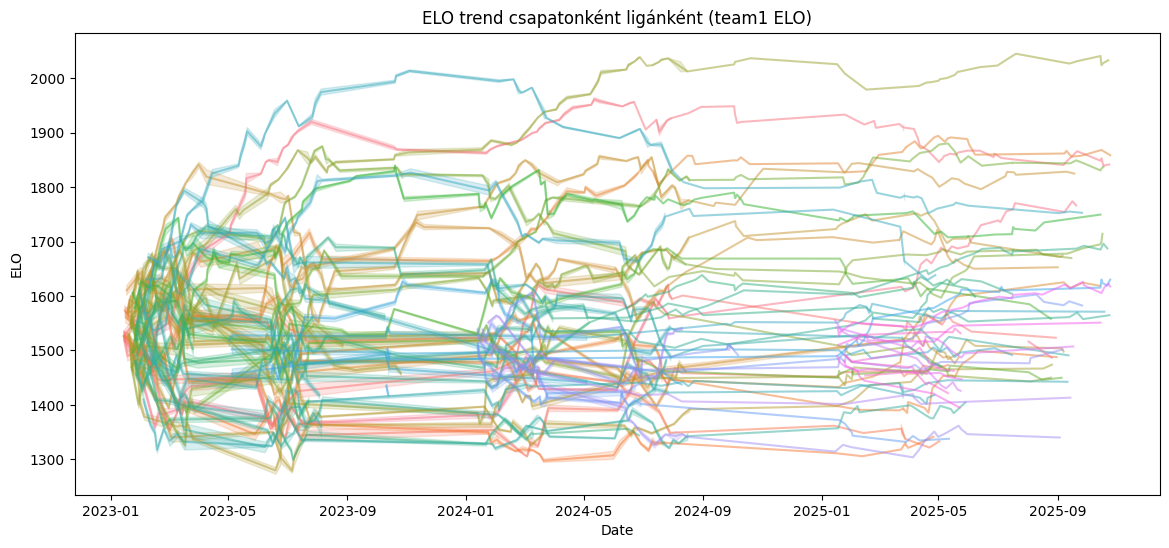

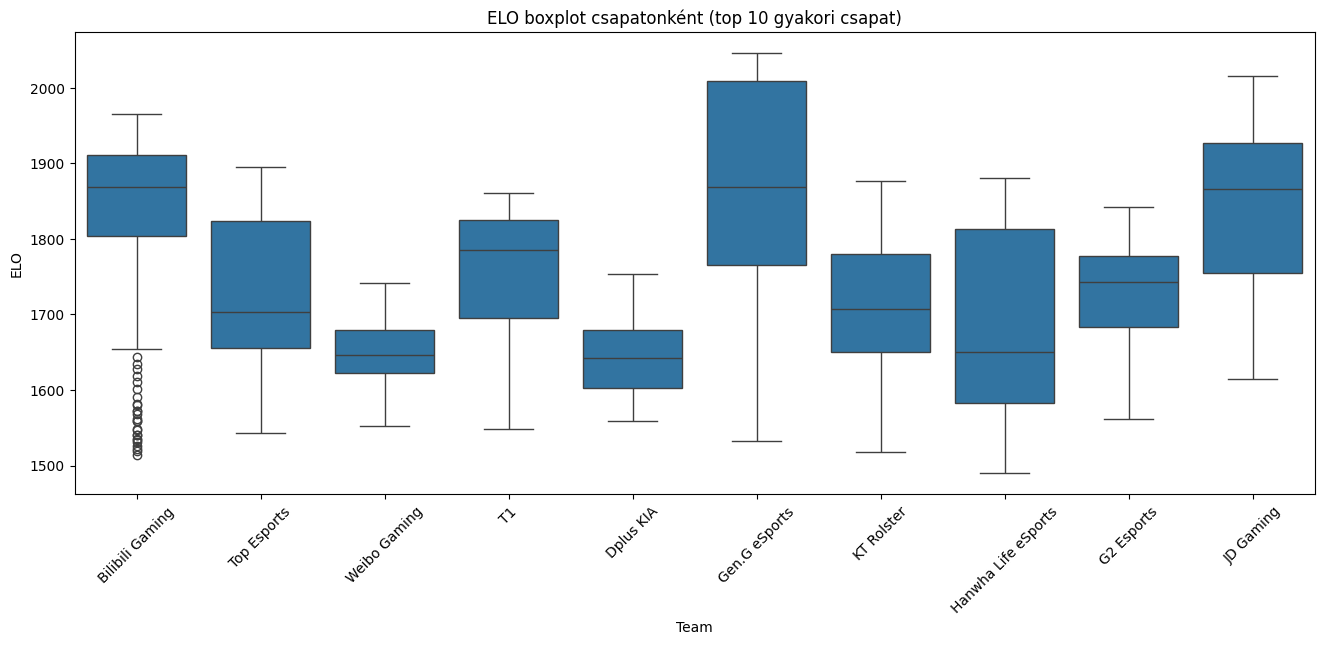

In [4]:
# ELO visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1️⃣ ELO rangsor jelenleg
# -------------------------------
# Kiszámítjuk a végső ELO-t minden csapatra (utolsó meccs után)
elo_latest_team1 = matches.groupby('team1')['team1_elo_after'].last()
elo_latest_team2 = matches.groupby('team2')['team2_elo_after'].last()

elo_latest = pd.concat([elo_latest_team1, elo_latest_team2], axis=1)
elo_latest['final_elo'] = elo_latest.max(axis=1)
elo_rank = elo_latest['final_elo'].sort_values(ascending=False)
print("=== Jelenlegi ELO rangsor ===")
print(elo_rank.head(10))

# -------------------------------
# 2️⃣ Upset / meglepetés meccsek
# -------------------------------
# Definiáljuk, hogy upset, ha a győztes ELO-ja legalább 100 ponttal kevesebb volt a vesztesnél
def detect_upset(row):
    if row['team1_score'] > row['team2_score'] and row['team1_elo_after'] + 100 < row['team2_elo_after']:
        return True
    elif row['team2_score'] > row['team1_score'] and row['team2_elo_after'] + 100 < row['team1_elo_after']:
        return True
    else:
        return False

matches['upset'] = matches.apply(detect_upset, axis=1)
num_upsets = matches['upset'].sum()
print(f"Number of upsets: {num_upsets}")

# -------------------------------
# 3️⃣ Ligánkénti ELO trend
# -------------------------------
plt.figure(figsize=(14,6))
sns.lineplot(data=matches, x='date', y='team1_elo_after', hue='team1', alpha=0.5)
plt.title("ELO trend csapatonként ligánként (team1 ELO)")
plt.xlabel("Date")
plt.ylabel("ELO")
plt.legend([],[], frameon=False)  # túl sok csapat, ezért elrejtjük a legend-et
plt.show()

# -------------------------------
# 4️⃣ ELO boxplot csapatonként
# -------------------------------
plt.figure(figsize=(16,6))
top_teams = matches['team1'].value_counts().nlargest(10).index  # Top 10 gyakori csapat
sns.boxplot(data=matches[matches['team1'].isin(top_teams)], x='team1', y='team1_elo_after')
plt.title("ELO boxplot csapatonként (top 10 gyakori csapat)")
plt.xlabel("Team")
plt.ylabel("ELO")
plt.xticks(rotation=45)
plt.show()

# Odds

## OddsPortal

In [ ]:
# Tournaments

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import time

def scrape_oddsportal_lol_links():
    url = "https://www.oddsportal.com/results/#esports"
    driver = webdriver.Chrome()
    driver.get(url)

    wait = WebDriverWait(driver, 15)
    # várjuk, amíg betöltődik legalább 1 tournament link
    wait.until(EC.presence_of_all_elements_located((By.CSS_SELECTOR, "li[data-testid='results-tournament-box'] a")))

    time.sleep(2)  # kis extra wait, hogy minden JS lefusson

    links = driver.find_elements(By.CSS_SELECTOR, "li[data-testid='results-tournament-box'] a")

    data = []
    for link in links:
        try:
            text = link.text.strip()
            href = link.get_attribute("href")
            if text.startswith("League of Legends "):
                name = text.replace("League of Legends ", "").strip()
                data.append({
                    "Name": name,
                    "url": href
                })
        except Exception as e:
            print(f"⚠️ Hiba egy link feldolgozásánál: {e}")
            continue

    driver.quit()
    df = pd.DataFrame(data)
    print(f"✅ {len(df)} League of Legends esemény található az OddsPortalon.")
    return df


# --- Példa futtatás ---
df_oddsportal = scrape_oddsportal_lol_links()
display(df_oddsportal)


In [ ]:
# Odds of tournament

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import re, time
from datetime import datetime

def scrape_oddsportal_fixed(event_url, headless=False):
    opts = webdriver.ChromeOptions()
    if headless:
        opts.add_argument("--headless=new")
    opts.add_argument("--no-sandbox")
    opts.add_argument("--disable-dev-shm-usage")
    opts.add_argument("user-agent=Mozilla/5.0")
    
    driver = webdriver.Chrome(options=opts)
    driver.get(event_url)
    wait = WebDriverWait(driver, 20)

    # --- Cookie gomb elfogadása, ha van ---
    try:
        cookie_btn = wait.until(EC.element_to_be_clickable((By.ID, "onetrust-accept-btn-handler")))
        cookie_btn.click()
        time.sleep(1)
        print("🍪 Cookie elfogadva")
    except:
        pass

    # --- 2023 és 2024 szezon linkek lekérdezése ---
    season_links = driver.find_elements(By.CSS_SELECTOR, "a[href*='/results/']")
    season_urls = []
    season_urls.append(event_url)
    for a in season_links:
        href = a.get_attribute("href")
        if re.search(r'2023/results/', href) or re.search(r'2024/results/', href):
            season_urls.append(href)

    # Ha nincs külön link, használjuk az eredeti event_url-t
    if not season_urls:
        season_urls = [event_url]

    all_data = []

    # --- Iterálunk a szezon linkeken ---
    for season_url in season_urls:
        driver.get(season_url)
        time.sleep(2)
        print(f"📅 Szezon feldolgozása: {season_url}")

        page = 1
        while True:
            print(f"🔍 Oldal {page} feldolgozása...")
            
            # Inkrementális scroll: lépésekben, lassabban
            scroll_pause = 1.5
            scroll_step = 500  # pixelenként
            last_height = driver.execute_script("return document.body.scrollHeight")
            current_pos = 0

            while current_pos < last_height:
                driver.execute_script(f"window.scrollTo(0, {current_pos});")
                time.sleep(scroll_pause)
                current_pos += scroll_step
                new_height = driver.execute_script("return document.body.scrollHeight")
                if new_height > last_height:
                    last_height = new_height


            time.sleep(2)
            wait.until(EC.presence_of_all_elements_located((By.CSS_SELECTOR, "div.eventRow")))

            event_rows = driver.find_elements(By.CSS_SELECTOR, "div.eventRow")
            current_date = None

            for event in event_rows:
                # dátum keresése
                date_found = False
                
                # Dátum keresése az event teljes szövegében
                date_text = event.text.strip()
                if any(month in date_text for month in ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']):
                    lines = date_text.split('\n')
                    for line in lines:
                        if any(month in line for month in ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']):
                            # Dátum formázása - eltávolítjuk a " -" utáni részt
                            clean_date = line.split(' -')[0].strip()
                            current_date = clean_date
                            
                            # Dátum átalakítása YYYY-MM-dd formátumba
                            try:
                                date_obj = datetime.strptime(current_date, '%d %b %Y')
                                current_date = date_obj.strftime('%Y-%m-%d')
                            except ValueError:
                                # Ha nem sikerül átalakítani, marad az eredeti
                                pass
                            
                            date_found = True
                            break

                # Ha nincs dátum, de van game-row, akkor meccs sor
                try:
                    game_row = event.find_element(By.CSS_SELECTOR, "div[data-testid='game-row']")
                except:
                    continue

                # csapatnevek
                participants = game_row.find_elements(By.CSS_SELECTOR, "a[title]")
                if len(participants) < 2:
                    continue

                home_team = participants[0].get_attribute("title").strip()
                away_team = participants[1].get_attribute("title").strip()

                # oddsok
                odds_blocks = event.find_elements(By.CSS_SELECTOR, "div[data-testid^='odd-container'] p")
                odds = []
                for p in odds_blocks:
                    try:
                        odds_text = p.text.strip().replace(",", ".")
                        if re.match(r"^\d+(\.\d+)?$", odds_text):
                            odds.append(float(odds_text))
                    except:
                        continue
                
                home_odds = odds[0] if len(odds) > 0 else None
                away_odds = odds[1] if len(odds) > 1 else None

                all_data.append({
                    "Date": current_date,
                    "home_team": home_team,
                    "away_team": away_team,
                    "home_odds": home_odds,
                    "away_odds": away_odds
                })

            # Következő oldal ellenőrzése
            try:
                next_button = driver.find_element(By.CSS_SELECTOR, f"a.pagination-link[data-number='{page + 1}']")
                if next_button.is_enabled():
                    print(f"➡️ Következő oldal: {page + 1}")
                    driver.execute_script("arguments[0].click();", next_button)
                    page += 1
                    time.sleep(3)  # Várakozás az oldal betöltésére
                    continue
                else:
                    break
            except:
                # Ha nincs következő oldal, kilépünk
                break

    driver.quit()
    
    df = pd.DataFrame(all_data).drop_duplicates(subset=["home_team","away_team","home_odds","away_odds"])
    print(f"✅ Összesen {len(df)} meccs feldolgozva {page} oldalról.")
    return df

# Teszt
#url = "https://www.oddsportal.com/esports/league-of-legends/league-of-legends-world-championship/results/"
#df_odds = scrape_oddsportal_fixed(url, headless=False)
#display(df_odds)

In [ ]:
# Relevant odds
  
oddsportal_relevant = [
    "LEC",
    "LCS Lock-In",
    "LTA North",
    "LTA South",
    "LTA Cross Conference",
    "LCP",
    "LCK",
    "LPL",
    "World Championship",
    "Esports World Cup"
]

df_odds_super = pd.DataFrame()
for op_tour in oddsportal_relevant:
    url_op = df_oddsportal[df_oddsportal.Name == op_tour]['url'].iloc[0]
    df_odds = scrape_oddsportal_fixed(url_op, headless=False)
    df_odds['tournament_op'] = op_tour
    df_odds_super = pd.concat([df_odds_super, df_odds], ignore_index=True)

display(df_odds_super)

In [ ]:
# Save odds super

df_odds_super['Date'] = pd.to_datetime(df_odds_super['Date'])
df_odds_super.sort_values('Date', inplace=True)
df_odds_super = df_odds_super.reset_index(drop=True)
display(df_odds_super)

df_odds_super.to_csv('data/odds.csv', index=False)

## Fuzzy match

In [ ]:
# Fuzzy matching JSON

import pandas as pd
from fuzzywuzzy import process
import json
from pathlib import Path
import re

# --- Helper függvény: normalizálás ---
def normalize_team_name(name):
    name = name.lower()
    # eltávolítjuk a 'team', 'gaming', 'esports' szavakat
    name = re.sub(r'\b(team|gaming|esports)\b', '', name)
    # extra whitespace eltávolítás
    name = re.sub(r'\s+', ' ', name).strip()
    return name

# --- Egyedi csapatnevek ---
odds_teams = pd.unique(df_odds_super[['home_team','away_team']].values.ravel())
match_teams = pd.unique(matches[['team1','team2']].values.ravel())

# --- Normalizált változatok készítése fuzzyhoz ---
normalized_match_teams = {normalize_team_name(t): t for t in match_teams}

team_mapping = {}
for team in odds_teams:
    norm_team = normalize_team_name(team)
    
    # fuzzy match a normalizált neveken
    best_match_norm, score = process.extractOne(norm_team, normalized_match_teams.keys())
    # visszakapjuk az eredeti matches csapatnevet
    matched_team = normalized_match_teams[best_match_norm]
    
    team_mapping[team] = {
        "matched_team": matched_team,
        "score": score
    }

# --- Mentés JSON-ba ---
#Path("data").mkdir(exist_ok=True)
#with open("data/team_name_mapping.json", "w", encoding="utf-8") as f:
#    json.dump(team_mapping, f, indent=2, ensure_ascii=False)

#print("✅ Normalizált fuzzy team mapping kész, elmentve: data/team_name_mapping.json")


In [24]:
# Map team names

import json

with open("data/team_name_mapping.json", "r", encoding="utf-8") as f:
    team_mapping = json.load(f)

df_odds_super = pd.read_csv('data/odds.csv')

for i, row in df_odds_super.iterrows():
    df_odds_super.loc[i, 'team1'] = team_mapping[row['home_team']]['matched_team']
    df_odds_super.loc[i, 'team2'] = team_mapping[row['away_team']]['matched_team']


# Matches mapping
## convert name and type
df_odds_super.rename(columns={'Date': 'date'}, inplace=True)
df_odds_super['date'] = pd.to_datetime(df_odds_super['date'])

## merge manually
for i, row in df_odds_super.iterrows():
    home_op = row['team1']
    away_op = row['team2']

    rel_matches = matches[(matches.date < row['date'] + pd.Timedelta(days=1)) & 
                          (matches.date > row['date'] - pd.Timedelta(days=1))]
    if rel_matches.shape[0] == 0:
        continue
    else:
        for j, match in rel_matches.iterrows():
            if home_op == match['team1'] and away_op == match['team2']:
                matches.loc[j, 'team1_odds'] = row['home_odds']
                matches.loc[j, 'team2_odds'] = row['away_odds']
            elif home_op == match['team2'] and away_op == match['team1']:
                matches.loc[j, 'team1_odds'] = row['away_odds']
                matches.loc[j, 'team2_odds'] = row['home_odds']

matches_o = matches[matches.team1_odds.notna()].reset_index(drop=True).copy()
display(matches_o.sample(7))
print(f"Matches with matched odds: {len(matches_o)}/{len(matches)}")

,tournament_name,match_id,match_name,team1,team1_score,team2,team2_score,total_games,week,patch,...,url,region,is_international,team1_elo_before,team2_elo_before,team1_elo_after,team2_elo_after,upset,team1_odds,team2_odds
10,LCK Cup 2025,63029,Dplus KIA vs DN Freecs,Dplus KIA,2.0,DN Freecs,0.0,2,WEEK1,15.10,...,https://gol.gg/game/stats/63029/page-summary/,LCK,0,1723.178448,1555.369728,1728.244354,1550.303822,False,1.29,3.41
484,LEC 2025 Summer Season,70367,TH vs Fnatic,Team Heretics,1.0,Fnatic,2.0,3,WEEK1,15.15,...,https://gol.gg/game/stats/70367/page-summary/,LEC,0,1464.792031,1668.622081,1460.066995,1673.347117,False,5.17,1.14
235,LPL 2025 Split 2,65713,AL vs WBG,Anyone s Legend,2.0,Weibo Gaming,0.0,2,WEEK2,15.70,...,https://gol.gg/game/stats/65713/page-summary/,LPL,0,1646.378892,1705.937359,1658.076526,1694.239725,False,1.49,2.50
450,LTA North 2025 Split 2 Playoffs,68815,FlyQuest vs Cloud9,FlyQuest,3.0,Cloud9,2.0,5,ROUND2,15.11,...,https://gol.gg/game/stats/68815/page-summary/,LCS,0,1669.043593,1631.056866,1677.954583,1622.145876,False,1.41,2.70
96,LCK Cup 2025,63993,Dplus KIA vs NS,Dplus KIA,3.0,Nongshim RedForce,1.0,4,PLAYOFFS-ROUND2,15.30,...,https://gol.gg/game/stats/63993/page-summary/,LCK,0,1747.633017,1439.756666,1750.263823,1437.125860,False,1.17,4.76
32,LPL 2025 Split 1,63078,Team WE vs LGD Gaming,LGD Gaming,3.0,Team WE,0.0,3,WEEK3,15.10,...,https://gol.gg/game/stats/63078/page-summary/,LPL,0,1451.214177,1404.636872,1459.881549,1395.969501,False,2.24,1.61
495,LEC 2025 Summer Season,71025,MKOI vs NAVI,Movistar KOI,2.0,Natus Vincere,0.0,2,WEEK3,15.16,...,https://gol.gg/game/stats/71025/page-summary/,LEC,0,1594.751736,1516.479082,1602.536224,1508.694594,False,1.07,7.13


Matches with matched odds: 584/5200


In [64]:
# ML features

import numpy as np

# --- 1️⃣ Tournament info integrálása matches_o-ba ---
ml_matches = matches.copy()

# Merge tournament metadata
ml_matches = pd.merge(ml_matches,
    tournaments[['tournament_name', 'region', 'split', 'stage']],
    how='left',
    on='tournament_name'
)

# --- 2️⃣ Elo alapú feature-ök ---
ml_matches['elo_diff'] = ml_matches['team1_elo_before'] - ml_matches['team2_elo_before']

# --- 3️⃣ Forma / momentum feature-ök ---
ml_matches = ml_matches.sort_values('date')
ml_matches['team1_win'] = (ml_matches['team1_score'] > ml_matches['team2_score']).astype(int)
ml_matches['team2_win'] = (ml_matches['team2_score'] > ml_matches['team1_score']).astype(int)

# Rolling window 5 meccs soronként
def rolling_winrate_rowwise(df, n=5):
    team1_winrates = []
    team2_winrates = []

    df_sorted = df.sort_values('date')

    for idx, row in df_sorted.iterrows():
        team1 = row['team1']
        team2 = row['team2']
        date = row['date']

        # --- Team1 winrate ---
        past_team1 = df_sorted[
            ((df_sorted['team1'] == team1) | (df_sorted['team2'] == team1)) &
            (df_sorted['date'] < date)
        ].sort_values('date', ascending=False).head(n)
        if len(past_team1) == 0:
            team1_winrates.append(np.nan)
        else:
            wins = sum(
                (m['team1_win'] if m['team1'] == team1 else m['team2_win'])
                for _, m in past_team1.iterrows()
            )
            team1_winrates.append(wins / len(past_team1))

        # --- Team2 winrate ---
        past_team2 = df_sorted[
            ((df_sorted['team1'] == team2) | (df_sorted['team2'] == team2)) &
            (df_sorted['date'] < date)
        ].sort_values('date', ascending=False).head(n)
        if len(past_team2) == 0:
            team2_winrates.append(np.nan)
        else:
            wins = sum(
                (m['team1_win'] if m['team1'] == team2 else m['team2_win'])
                for _, m in past_team2.iterrows()
            )
            team2_winrates.append(wins / len(past_team2))

    return team1_winrates, team2_winrates

ml_matches['team1_winrate_5'], ml_matches['team2_winrate_5'] = rolling_winrate_rowwise(ml_matches, n=5)
ml_matches['team1_winrate_10'], ml_matches['team2_winrate_10'] = rolling_winrate_rowwise(ml_matches, n=10)

# --- 4️⃣ BO / patch / stage feature-ök ---
ml_matches['patch'] = ml_matches['patch'].astype(str)
ml_matches['is_playoffs'] = ml_matches['tournament_name'].str.contains('Playoffs|Finals|Championship', case=False).astype(int)

# --- 5️⃣ Games statisztika aggregálás (match szintre) ---
def assign_team_sides(row, team1, team2):
    if row['blue_team'] == team1:
        # team1 = blue, team2 = red
        return pd.Series({
            'team1_gold_diff_15min': row['gold_diff_15min'],
            'team2_gold_diff_15min': -row['gold_diff_15min'],
            'team1_first_blood': row['blue_first_blood'],
            'team2_first_blood': row['red_first_blood'],
            'team1_first_tower': row['blue_first_tower'],
            'team2_first_tower': row['red_first_tower'],
            'team1_barons': row['blue_barons'],
            'team2_barons': row['red_barons'],
            'team1_dragons': row['blue_dragons'],
            'team2_dragons': row['red_dragons'],
            'team1_wards_destroyed': row['vision_team1_wards_destroyed'],
            'team1_wards_placed': row['vision_team1_wards_placed'],
            'team2_wards_destroyed': row['vision_team2_wards_destroyed'],
            'team2_wards_placed': row['vision_team2_wards_placed'],
        })
    else:
        # team1 = red, team2 = blue
        return pd.Series({
            'team1_gold_diff_15min': -row['gold_diff_15min'],
            'team2_gold_diff_15min': row['gold_diff_15min'],
            'team1_first_blood': row['red_first_blood'],
            'team2_first_blood': row['blue_first_blood'],
            'team1_first_tower': row['red_first_tower'],
            'team2_first_tower': row['blue_first_tower'],
            'team1_barons': row['red_barons'],
            'team2_barons': row['blue_barons'],
            'team1_dragons': row['red_dragons'],
            'team2_dragons': row['blue_dragons'],
            'team1_wards_destroyed': row['vision_team2_wards_destroyed'],  # figyelem: a vision_team1_wards a blue oldalra vonatkozik
            'team1_wards_placed': row['vision_team2_wards_placed'],
            'team2_wards_destroyed': row['vision_team1_wards_destroyed'],
            'team2_wards_placed': row['vision_team1_wards_placed'],
        })

# Merge minden match_id-re
all_features = []
for idx, match in ml_matches.iterrows():
    match_games = games[games['match_id'] == match['match_id']].copy()
    team1 = match['team1']
    team2 = match['team2']
    temp = match_games.apply(assign_team_sides, axis=1, team1=team1, team2=team2)
    # Átlag, összeg vagy arányosítás
    temp_agg = temp.mean()  # pl. átlag minden game-re
    temp_agg['match_id'] = match['match_id']
    all_features.append(temp_agg)

games_agg_corrected = pd.DataFrame(all_features)
games_agg_corrected = games_agg_corrected.groupby('match_id', as_index=False).mean()

ml_matches = ml_matches.merge(games_agg_corrected, on='match_id', how='left')

# --- 6️⃣ Vision és objective control arányok ---
ml_matches['team1_vision_control'] = ml_matches['team1_wards_destroyed'] / (ml_matches['team1_wards_placed'] + 1)
ml_matches['team2_vision_control'] = ml_matches['team2_wards_destroyed'] / (ml_matches['team2_wards_placed'] + 1)

ml_matches['team1_dragon_control'] = ml_matches['team1_dragons'] / (ml_matches['team1_dragons'] + ml_matches['team2_dragons'] + 1)
ml_matches['team2_dragon_control'] = ml_matches['team2_dragons'] / (ml_matches['team1_dragons'] + ml_matches['team2_dragons'] + 1)

ml_matches['team1_baron_control'] = ml_matches['team1_barons'] / (ml_matches['team1_barons'] + ml_matches['team2_barons'] + 1)
ml_matches['team2_baron_control'] = ml_matches['team2_barons'] / (ml_matches['team1_barons'] + ml_matches['team2_barons'] + 1)

# --- 7️⃣ Kimenetel target --- 
ml_matches['target'] = (ml_matches['team1_score'] > ml_matches['team2_score']).astype(int)

# --- 8️⃣ ML input kész ---
ml_features = [
    'team1_elo_before', 'team2_elo_before', 'elo_diff',
    'team1_winrate_5', 'team2_winrate_5',
    'team1_winrate_10', 'team2_winrate_10',
    'patch', 'is_playoffs', 'is_international',
    'team1_vision_control', 'team2_vision_control',
    'team1_dragon_control', 'team2_dragon_control',
    'team1_baron_control', 'team2_baron_control'
]

ml_df = ml_matches[ml_features + ['target', 'match_id', 'date', 'tournament_name', 'team1', 'team2']].copy()
ml_df.fillna(0, inplace=True)

print("✅ ML input kész, shape:", ml_df.shape)
display(ml_df.tail())

✅ ML input kész, shape: (5200, 22)


,team1_elo_before,team2_elo_before,elo_diff,team1_winrate_5,team2_winrate_5,team1_winrate_10,team2_winrate_10,patch,is_playoffs,is_international,...,team1_dragon_control,team2_dragon_control,team1_baron_control,team2_baron_control,target,match_id,date,tournament_name,team1,team2
5195,1839.602531,1501.491648,338.110883,0.6,0.4,0.6,0.333333,15.2,0,1,...,0.545455,0.272727,0.600000,0.000000,1,72927,2025-10-24,Worlds 2025 Main Event,Bilibili Gaming,Vivo Keyd Stars
5196,1569.210457,1814.072329,-244.861872,0.4,0.4,0.5,0.500000,15.2,0,1,...,0.230769,0.615385,0.200000,0.400000,0,72930,2025-10-24,Worlds 2025 Main Event,100 Thieves,T1
5197,1849.818316,1841.772031,8.046285,0.4,0.6,0.6,0.600000,15.2,0,1,...,0.470588,0.352941,0.333333,0.166667,1,72947,2025-10-25,Worlds 2025 Main Event,Top Esports,Bilibili Gaming
5198,1623.058434,1818.528246,-195.469812,0.6,0.6,0.6,0.600000,15.2,0,1,...,0.214286,0.642857,0.000000,0.600000,0,72950,2025-10-25,Worlds 2025 Main Event,Movistar KOI,T1
5199,1619.059809,1687.634449,-68.574640,0.4,0.6,0.4,0.600000,15.2,0,1,...,0.500000,0.333333,0.400000,0.200000,1,72944,2025-10-25,Worlds 2025 Main Event,CTBC Flying Oyster,FlyQuest


In [82]:
# ML betting sim

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- 1️⃣ Csak azokat a meccseket tartjuk meg, amelyekhez vannak oddsok ---
ml_df_odds = ml_df[ml_df['match_id'].isin(matches_o['match_id'])].copy()

# --- 2️⃣ Merge-eljük az oddsokat ---
ml_df_odds = ml_df_odds.merge(
    matches_o[['match_id', 'team1_odds', 'team2_odds']],
    on='match_id',
    how='left'
)

# --- 3️⃣ ML feature/target előkészítés ---
features = [
    'team1_elo_before', 'team2_elo_before', 'elo_diff',
    'team1_winrate_5', 'team2_winrate_5',
    'team1_winrate_10', 'team2_winrate_10',
    'is_playoffs', 'is_international',
    'team1_vision_control', 'team2_vision_control',
    'team1_dragon_control', 'team2_dragon_control',
    'team1_baron_control', 'team2_baron_control'
]

X = ml_df_odds[features].copy()
y = ml_df_odds['target']

# --- 4️⃣ Train/test split idősoros módon (80% train, 20% test) ---
ml_df_odds = ml_df_odds.sort_values('date')
split_idx = int(0.8 * len(ml_df_odds))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
ml_test = ml_df_odds.iloc[split_idx:].copy()  # idősoros metrikákhoz

# --- 5️⃣ Random Forest modell ---
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # P(team1 wins)
y_pred = (y_pred_proba > 0.5).astype(int)

# --- 6️⃣ Pontosság ---
acc = accuracy_score(y_test, y_pred)
print(f"✅ Test accuracy: {acc:.3f}")

# --- 7️⃣ Value betting szimuláció ---
bankroll = 30.0  # kezdő bankroll
unit = 1.0       # 1 egység / tét
value_bets = 0

results = []

for idx, row in ml_test.iterrows():
    p_team1 = model.predict_proba([row[features]])[0][1]
    p_team2 = 1 - p_team1
    # Value bet logika: ha az odds + valószínűség > 1
    if p_team1 > 0 and (row['team1_odds'] * p_team1 - 1) > 0:
        value_bets += 1
        win = row['target'] == 1
        bankroll += unit * (row['team1_odds'] - 1) if win else -unit
        results.append({'match_id': row['match_id'], 'team': row['team1'], 'win': win, 'odds': row['team1_odds']})
    if p_team2 > 0 and (row['team2_odds'] * p_team2 - 1) > 0:
        value_bets += 1
        win = row['target'] == 0
        bankroll += unit * (row['team2_odds'] - 1) if win else -unit
        results.append({'match_id': row['match_id'], 'team': row['team2'], 'win': win, 'odds': row['team2_odds']})

# --- 8️⃣ Eredmények ---
roi = (bankroll - 30.0) / 30.0 * 100
print(f"✅ Value bets count: {value_bets}")
print(f"✅ Final bankroll: {bankroll:.2f}")
print(f"✅ ROI: {roi:.2f}%")

# --- 9️⃣ Opció: results dataframe ---
results_df = pd.DataFrame(results)
display(results_df.head())


✅ Test accuracy: 0.906


c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\

✅ Value bets count: 109
✅ Final bankroll: 95.41
✅ ROI: 218.03%


c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Adam\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\

,match_id,team,win,odds
0,69571,CTBC Flying Oyster,True,1.30
1,69572,FURIA,True,2.84
2,69569,Hanwha Life eSports,True,1.16
3,69568,Cloud9,False,2.36
4,69566,Movistar KOI,True,1.41


In [86]:
# vs Baseline: favorit bet

import pandas as pd

# Feltételezve, hogy az oddsok már benne vannak ml_df-ben: 'team1_odds', 'team2_odds'
# És a target: 1 ha team1 nyer, 0 ha team2

# 1️⃣ Kiszámoljuk a favorit csapatot minden sorban
def get_favorite(row):
    if row['team1_odds'] < row['team2_odds']:
        return 'team1'
    else:
        return 'team2'

ml_df_odds['favorite'] = ml_df_odds.apply(get_favorite, axis=1)

# 2️⃣ Kimenetel ellenőrzése a favoritra
def favorite_win(row):
    if row['favorite'] == 'team1':
        return row['target'] == 1
    else:
        return row['target'] == 0

ml_df_odds['favorite_win'] = ml_df_odds.apply(favorite_win, axis=1)

# 3️⃣ Szimuláció
bankroll_bl = 30  # kezdő bankroll
bet_unit = 1
wins = 0
for idx, row in ml_df_odds.iterrows():
    odds = row['team1_odds'] if row['favorite'] == 'team1' else row['team2_odds']
    if row['favorite_win']:
        bankroll_bl += bet_unit * (odds - 1)  # profit
        wins += 1
    else:
        bankroll_bl -= bet_unit  # veszteség

# 4️⃣ Eredmények
accuracy_bl = ml_df_odds['favorite_win'].mean()
roi_bl = (bankroll_bl - 30) / 30 * 100  # ROI százalékban

print(f"Favorite betting count: {len(ml_df_odds)}")
print(f"Wins: {wins}")
print(f"Final bankroll: {bankroll_bl:.2f} (model: {bankroll:.2f})")
print(f"Accuracy: {accuracy_bl:.3f} (model: {acc:.2f})")
print(f"ROI: {roi_bl:.0f}% (model: {roi:.0f}%)")


Favorite betting count: 584
Wins: 433
Final bankroll: 15.81 (model: 95.41)
Accuracy: 0.741 (model: 0.91)
ROI: -47% (model: 218%)


In [87]:
# vs ELO bet

import pandas as pd
import numpy as np

# Feltételezve, hogy ml_df_odds tartalmaz: 'team1_elo_before', 'team2_elo_before', 'team1_odds', 'team2_odds', 'target'

# 1️⃣ ELO alapú win valószínűség
def elo_win_prob(row):
    return 1 / (1 + 10 ** ((row['team2_elo_before'] - row['team1_elo_before']) / 400))

ml_df_odds['team1_prob'] = ml_df_odds.apply(elo_win_prob, axis=1)
ml_df_odds['team2_prob'] = 1 - ml_df_odds['team1_prob']

# 2️⃣ Value bet logika
def value_bet(row):
    # team1 value bet?
    if row['team1_odds'] * row['team1_prob'] > 1:
        return 'team1'
    elif row['team2_odds'] * row['team2_prob'] > 1:
        return 'team2'
    else:
        return None

ml_df_odds['value_bet'] = ml_df_odds.apply(value_bet, axis=1)

# 3️⃣ Szimuláció
bankroll_vb = 30
bet_unit = 1
wins_vb = 0
value_bets_count = 0

for idx, row in ml_df_odds.iterrows():
    if row['value_bet'] is not None:
        value_bets_count += 1
        odds = row['team1_odds'] if row['value_bet'] == 'team1' else row['team2_odds']
        won = (row['target'] == 1 and row['value_bet'] == 'team1') or \
              (row['target'] == 0 and row['value_bet'] == 'team2')
        if won:
            bankroll_vb += bet_unit * (odds - 1)
            wins_vb += 1
        else:
            bankroll_vb -= bet_unit

# 4️⃣ Eredmények
accuracy_vb = wins_vb / value_bets_count if value_bets_count > 0 else np.nan
roi_vb = (bankroll_vb - 30) / 30 * 100

print(f"✅ Value bets count: {value_bets_count}")
print(f"✅ Wins: {wins_vb}")
print(f"✅ Final bankroll: {bankroll_vb:.2f}")
print(f"✅ Accuracy: {accuracy_vb:.3f}")
print(f"✅ ROI: {roi_vb:.0f}%")


✅ Value bets count: 468
✅ Wins: 190
✅ Final bankroll: -13.15
✅ Accuracy: 0.406
✅ ROI: -144%


                 feature  importance
11   team2_baron_control    0.210543
9   team2_dragon_control    0.199353
8   team1_dragon_control    0.194495
10   team1_baron_control    0.192256
6   team1_vision_control    0.064315
7   team2_vision_control    0.046792
3       team2_winrate_10    0.025859
2       team1_winrate_10    0.024756
0        team1_winrate_5    0.019524
1        team2_winrate_5    0.018261
4            is_playoffs    0.003569
5       is_international    0.000277


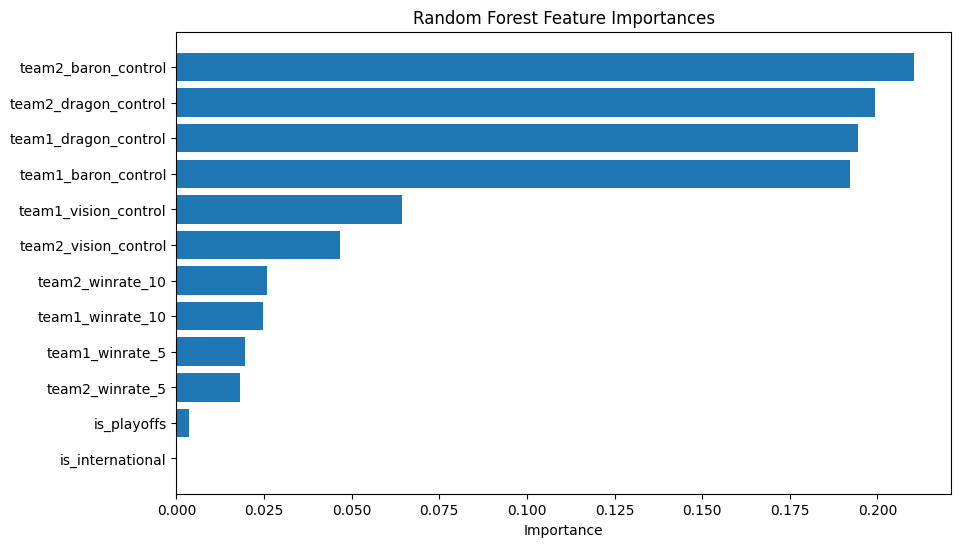

In [75]:
# Feature importance

import pandas as pd
import matplotlib.pyplot as plt

# Feltételezve, hogy a modell neve rf és a feature lista X.columns
importances = model.feature_importances_
feature_names = X.columns

# DataFrame-be pakoljuk
feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False)

# Kiíratás
print(feat_imp)

# Vizu
plt.figure(figsize=(10,6))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()  # a legfontosabb fent legyen
plt.xlabel('Importance')
plt.title('Random Forest Feature Importances')
plt.show()

